# 🔍 Phase 02 — Exploratory Data Analysis (EDA)

**What is EDA?**  
Before building any model, we *look at the data* to understand it.  
We ask questions like:
- Are fraud transactions bigger or smaller in amount?
- Do fraudsters strike more at night?
- Which card types are used more in fraud?

This phase produces **no model** — it produces insights we carry into Phase 03 and Phase 05.

## 2.1 — Setup: Load Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# Load the cleaned data we saved at the end of Phase 01
df = pd.read_csv('content/sample_data/df_preprocessed.csv')

print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print(f'Fraud   : {df["isFraud"].sum():,} transactions ({df["isFraud"].mean()*100:.1f}%)')

Rows    : 590,540
Columns : 434
Fraud   : 20,663 transactions (3.5%)


## 2.2 — Fraud Rate by Product Type

`ProductCD` describes what kind of product or service the transaction was for.  
It has only 5 categories: **W, H, C, S, R** — but each has a very different fraud rate.  

This is our first real insight: fraud is not evenly distributed across product types.  
In Phase 03, `ProductCD` will become an entity node in the graph — and this plot justifies why.

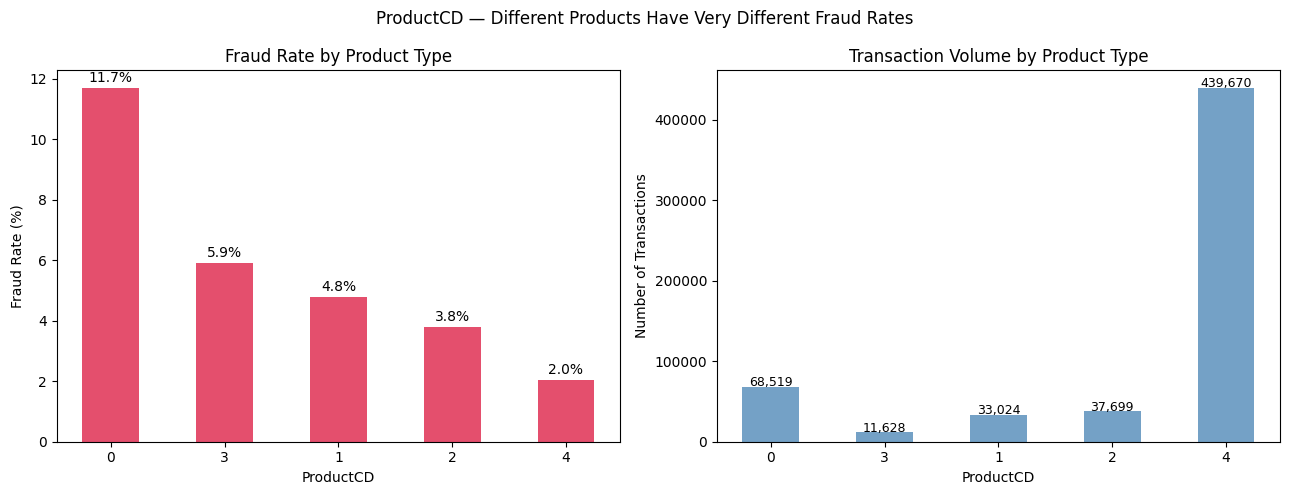

ProductCD will become an entity node in Phase 03 — this plot justifies that decision.


In [2]:
product_stats = df.groupby('ProductCD').agg(
    fraud_rate=('isFraud', 'mean'),
    count=('isFraud', 'count')
).sort_values('fraud_rate', ascending=False)
product_stats['fraud_rate'] = product_stats['fraud_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: fraud rate per product
axes[0].bar(product_stats.index.astype(str), product_stats['fraud_rate'],
            color='crimson', alpha=0.75, width=0.5)
axes[0].set_title('Fraud Rate by Product Type')
axes[0].set_xlabel('ProductCD')
axes[0].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(product_stats['fraud_rate']):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10)

# Right: volume per product
axes[1].bar(product_stats.index.astype(str), product_stats['count'],
            color='steelblue', alpha=0.75, width=0.5)
axes[1].set_title('Transaction Volume by Product Type')
axes[1].set_xlabel('ProductCD')
axes[1].set_ylabel('Number of Transactions')
for i, v in enumerate(product_stats['count']):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('ProductCD — Different Products Have Very Different Fraud Rates', fontsize=12)
plt.tight_layout()
plt.show()

print('ProductCD will become an entity node in Phase 03 — this plot justifies that decision.')

## 2.3 — Do Fraudsters Spend Differently?

**Question:** Are fraud transactions larger or smaller than legitimate ones?  
We compare the distribution of transaction amounts between both groups.

We use a **log scale** because a few very large transactions would compress everything else into the left edge and make the chart unreadable.

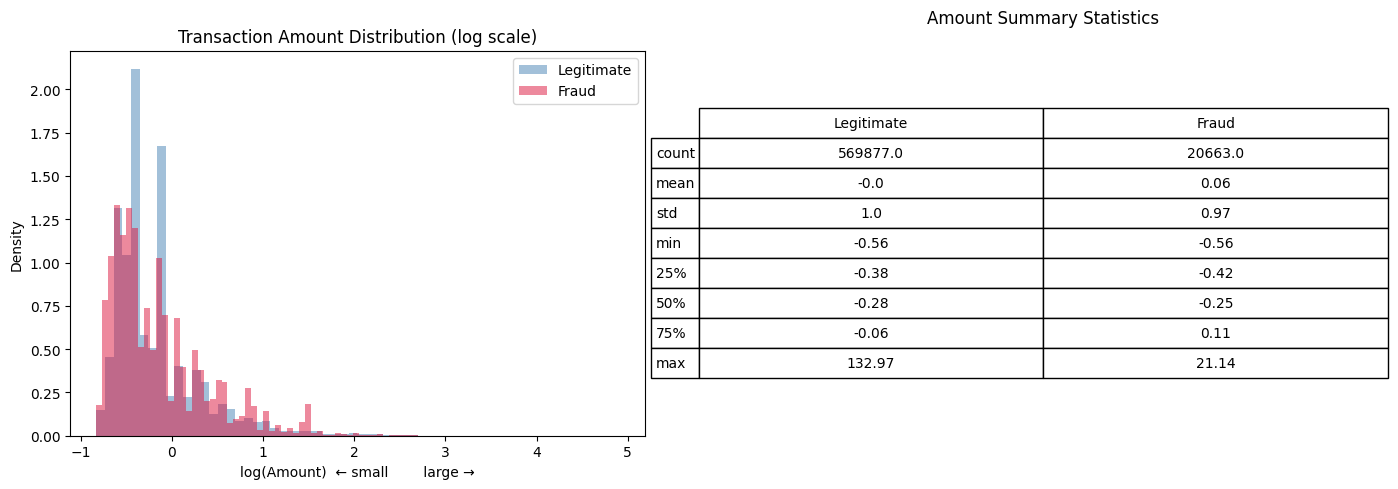

In [3]:
legit = df[df['isFraud'] == 0]['TransactionAmt']
fraud = df[df['isFraud'] == 1]['TransactionAmt']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution overlap
axes[0].hist(np.log1p(legit), bins=60, alpha=0.5, color='steelblue',
             label='Legitimate', density=True)
axes[0].hist(np.log1p(fraud), bins=60, alpha=0.5, color='crimson',
             label='Fraud', density=True)
axes[0].set_title('Transaction Amount Distribution (log scale)')
axes[0].set_xlabel('log(Amount)  ← small        large →')
axes[0].set_ylabel('Density')
axes[0].legend()

# Summary stats
stats = pd.DataFrame({
    'Legitimate': legit.describe(),
    'Fraud': fraud.describe()
})
axes[1].axis('off')
table = axes[1].table(cellText=stats.round(2).values,
                      rowLabels=stats.index,
                      colLabels=stats.columns,
                      cellLoc='center', loc='center')
table.scale(1.2, 1.8)
axes[1].set_title('Amount Summary Statistics', pad=20)

plt.tight_layout()
plt.show()

## 2.4 — When Does Fraud Happen?

`TransactionDT` is **seconds elapsed from an unknown reference point** — it is not a real calendar timestamp.  
We can extract a relative hour of day by taking `seconds mod 86400` (seconds in a day) then dividing by 3600.

> ⚠️ **Caveat:** Because the reference point is unknown, we cannot confirm hour 0 actually corresponds to midnight. The pattern below is relative — it shows *when within a 24-hour cycle* fraud spikes, but the absolute hours may be offset from real-world time.

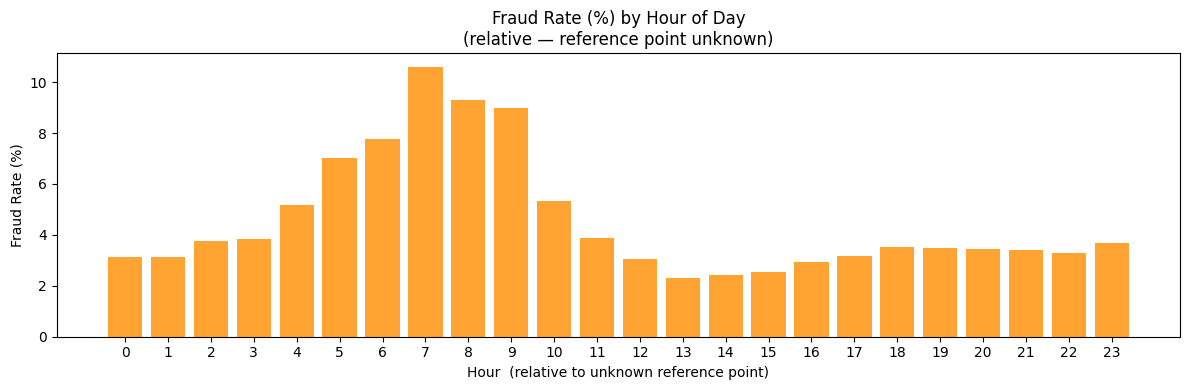

Fraud peaks at relative hour 7:00  (10.6% fraud rate at this hour)
Note: absolute hour values depend on the unknown reference point of TransactionDT.


In [4]:
df['hour'] = (df['TransactionDT'] % (3600 * 24)) // 3600

hourly = df.groupby('hour')['isFraud'].mean() * 100

plt.figure(figsize=(12, 4))
plt.bar(hourly.index, hourly.values, color='darkorange', alpha=0.8)
plt.title('Fraud Rate (%) by Hour of Day\n(relative — reference point unknown)')
plt.xlabel('Hour  (relative to unknown reference point)')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

peak = hourly.idxmax()
print(f'Fraud peaks at relative hour {peak}:00  ({hourly[peak]:.1f}% fraud rate at this hour)')
print('Note: absolute hour values depend on the unknown reference point of TransactionDT.')

## 2.5 — Which Card Types Are Used in Fraud?

We look at fraud rate across three key categorical columns that will become **graph nodes** in Phase 03.  
If a category has a clearly higher fraud rate than others, it means that node will carry real signal during message passing.

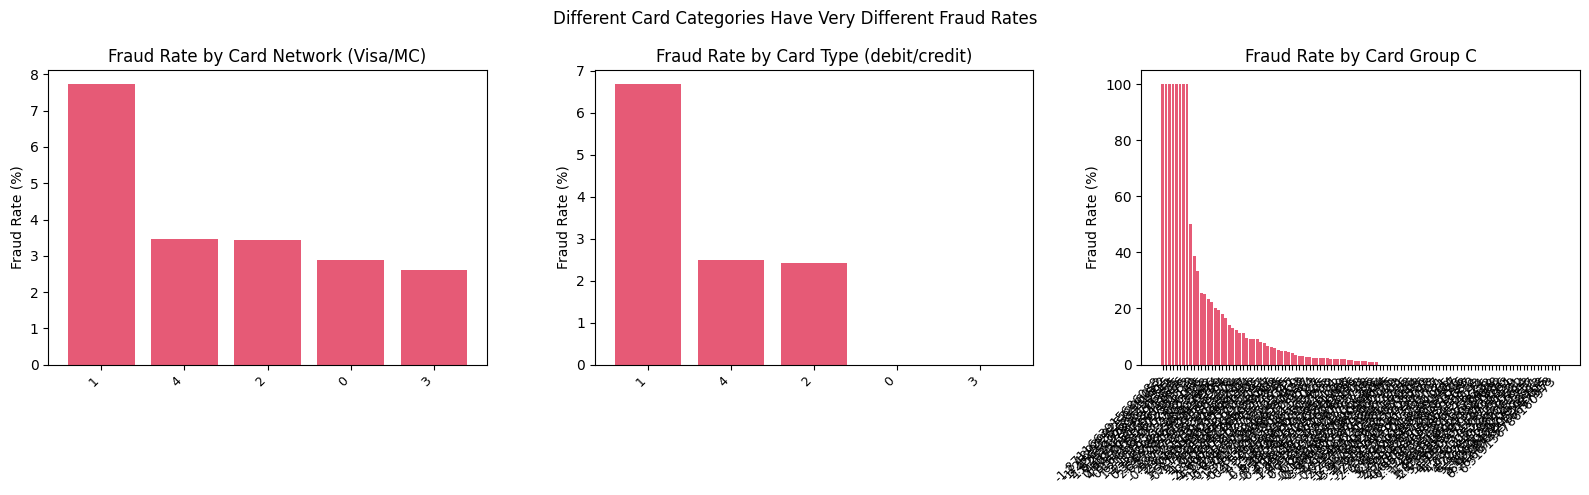

High variance across categories = these columns are useful graph nodes in Phase 03.


In [5]:
entity_cols = {
    'card4': 'Card Network (Visa/MC)',
    'card6': 'Card Type (debit/credit)',
    'card3': 'Card Group C',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, title) in zip(axes, entity_cols.items()):
    stats = df.groupby(col)['isFraud'].mean().sort_values(ascending=False) * 100
    ax.bar(range(len(stats)), stats.values, color='crimson', alpha=0.7)
    ax.set_xticks(range(len(stats)))
    ax.set_xticklabels(stats.index.astype(str), rotation=45, ha='right', fontsize=9)
    ax.set_title(f'Fraud Rate by {title}')
    ax.set_ylabel('Fraud Rate (%)')

plt.suptitle('Different Card Categories Have Very Different Fraud Rates', fontsize=12)
plt.tight_layout()
plt.show()

print('High variance across categories = these columns are useful graph nodes in Phase 03.')

## 2.6 — Which Email Domains Are Riskiest?

Email domains are important entity nodes in our graph.  
If gmail users have a different fraud rate than hotmail users, then the graph edges connecting transactions through email domains will carry real signal during message passing.

We look at both the **purchaser** email domain and the **recipient** email domain.

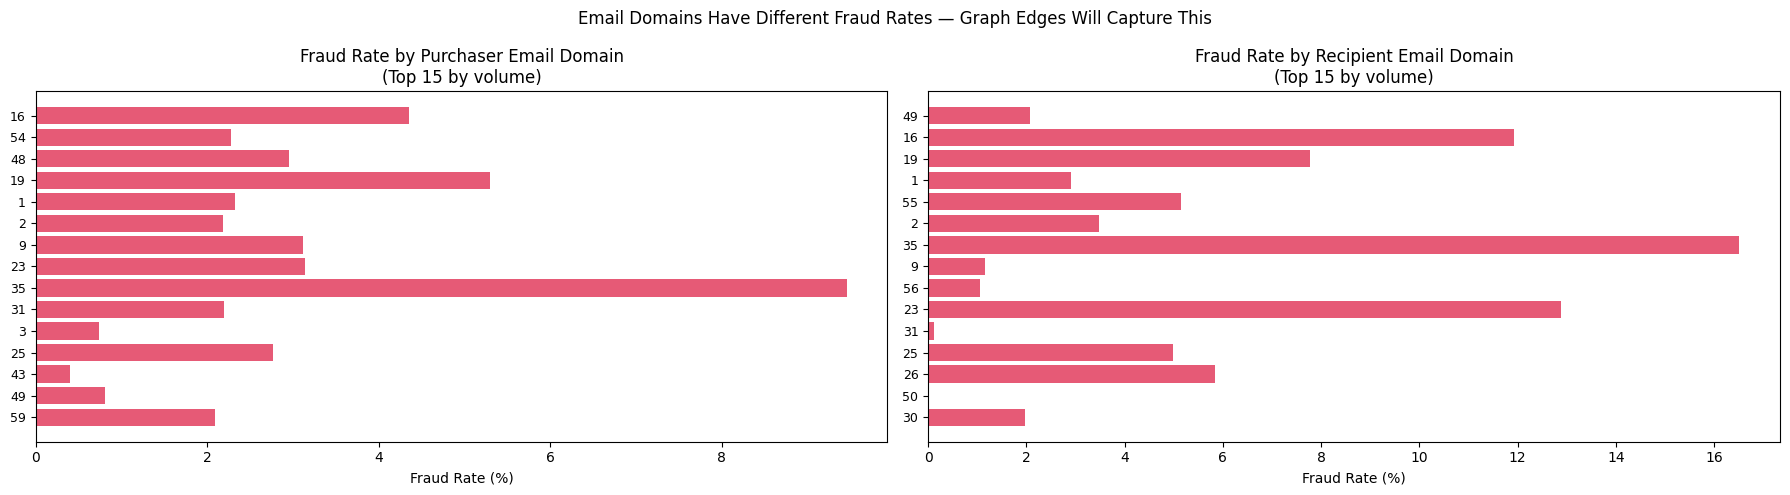

Email domains are strong candidates for graph nodes in Phase 03.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, col, title in zip(axes,
                           ['P_emaildomain', 'R_emaildomain'],
                           ['Purchaser Email Domain', 'Recipient Email Domain']):
    domain_stats = df.groupby(col).agg(
        fraud_rate=('isFraud', 'mean'),
        count=('isFraud', 'count')
    ).sort_values('count', ascending=False).head(15)
    domain_stats['fraud_rate'] = domain_stats['fraud_rate'] * 100

    ax.barh(range(len(domain_stats)), domain_stats['fraud_rate'],
            color='crimson', alpha=0.7)
    ax.set_yticks(range(len(domain_stats)))
    ax.set_yticklabels(domain_stats.index.astype(str), fontsize=9)
    ax.set_xlabel('Fraud Rate (%)')
    ax.set_title(f'Fraud Rate by {title}\n(Top 15 by volume)')
    ax.invert_yaxis()

plt.suptitle('Email Domains Have Different Fraud Rates — Graph Edges Will Capture This', fontsize=12)
plt.tight_layout()
plt.show()

print('Email domains are strong candidates for graph nodes in Phase 03.')

## 2.7 — Which V-Features Correlate With Fraud?

The dataset has **339 V-features** engineered by Vesta. We don't know what they represent, but we can measure which ones are most correlated with fraud.

We select the **top 40** by absolute correlation as the node features we'll feed into the GNN.  
Why 40? It's a practical balance — enough to capture the strongest signals without flooding the model with noisy features that slow training and hurt generalization. Features below the top 40 have very low correlation and contribute more noise than signal.

Total V-features: 339


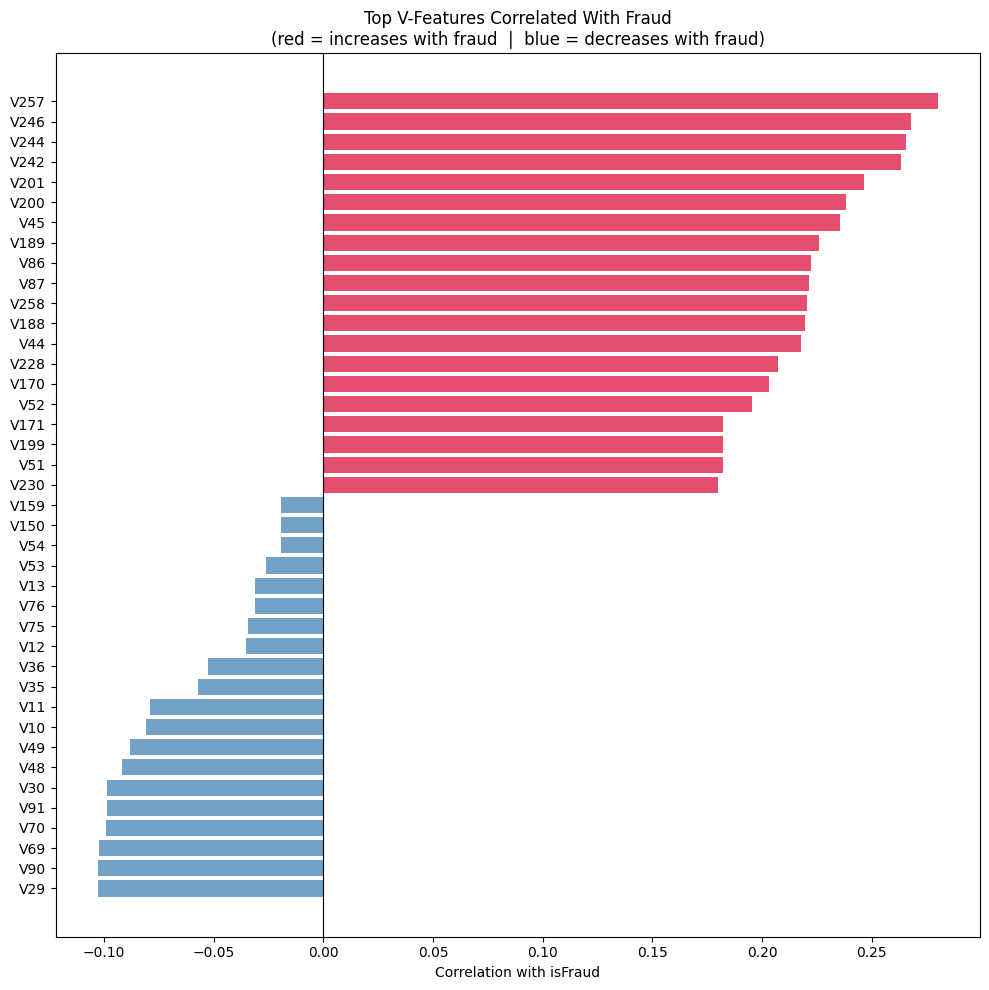

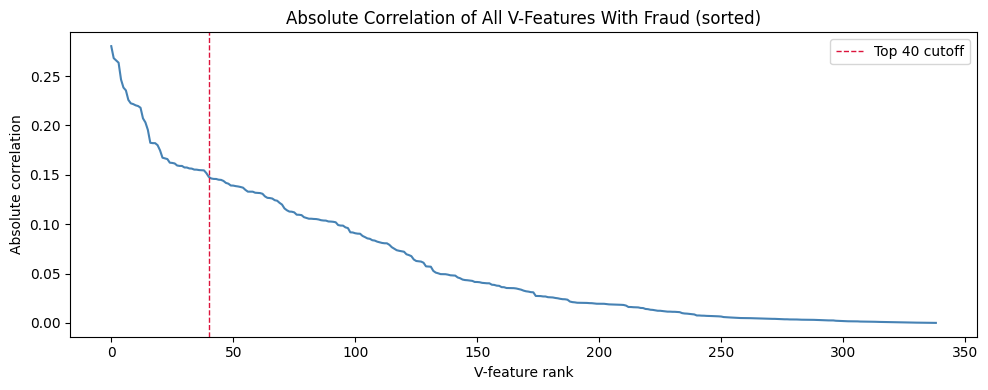

Saved top 40 V-features → useful_v_features.json
['V257', 'V246', 'V244', 'V242', 'V201', 'V200', 'V45', 'V189', 'V86', 'V87'] ... and 30 more


In [7]:
v_cols = [c for c in df.columns if c.startswith('V')]
print(f'Total V-features: {len(v_cols)}')

corr = df[v_cols + ['isFraud']].corr()['isFraud'].drop('isFraud')

# Top 20 positive + top 20 negative correlations
top_corr = pd.concat([corr.nlargest(20), corr.nsmallest(20)]).sort_values()

plt.figure(figsize=(10, 10))
colors = ['crimson' if v > 0 else 'steelblue' for v in top_corr.values]
plt.barh(top_corr.index, top_corr.values, color=colors, alpha=0.75)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top V-Features Correlated With Fraud\n(red = increases with fraud  |  blue = decreases with fraud)')
plt.xlabel('Correlation with isFraud')
plt.tight_layout()
plt.show()

# Plot the drop-off in correlation strength to justify the 40-feature cutoff
abs_corr_sorted = corr.abs().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
plt.plot(range(len(abs_corr_sorted)), abs_corr_sorted.values, color='steelblue')
plt.axvline(40, color='crimson', linestyle='--', linewidth=1, label='Top 40 cutoff')
plt.title('Absolute Correlation of All V-Features With Fraud (sorted)')
plt.xlabel('V-feature rank')
plt.ylabel('Absolute correlation')
plt.legend()
plt.tight_layout()
plt.show()

# Save the top 40 for Phase 03
useful_v_features = corr.abs().nlargest(40).index.tolist()
with open('content/sample_data/useful_v_features.json', 'w') as f:
    json.dump(useful_v_features, f)

print(f'Saved top {len(useful_v_features)} V-features → useful_v_features.json')
print(useful_v_features[:10], '... and 30 more')

## 2.8 — EDA Summary

What we learned and how it feeds into the next phases:

| Finding | Implication |
|---|---|
| 3.5% fraud rate — heavy imbalance | Use weighted loss in Phase 05, AUC-ROC and F1 in Phase 06 |
| ProductCD has very different fraud rates per category | `ProductCD` becomes an entity node in Phase 03 |
| Transaction amounts differ between fraud and legit | `TransactionAmt` is a meaningful node feature |
| Fraud rate varies across hours of day | Temporal patterns exist even without real timestamps |
| Card network and type affect fraud rate | `card4`, `card6` are useful graph nodes |
| Email domains have very different fraud rates | `P_emaildomain`, `R_emaildomain` are strong graph nodes |
| Top 40 V-features have meaningful correlation with fraud | Use these as transaction node features in Phase 03 |

**Next → Phase 03: Graph Construction**